# Bank Customer Churn Prediction and Analysis
### A Complete End-to-End Data Science Project

---

**Author:** Abdul Moez Abbasi

**Dataset:** Bank Customer Churn (Kaggle)  

**Tools:** Python, Pandas, Scikit-learn, XGBoost, SHAP, Matplotlib, Seaborn

---

## Project Overview

Customer churn — when a customer stops doing business with a company, is one of the most costly problems in banking. Acquiring a new customer costs significantly more than retaining an existing one. By predicting which customers are likely to leave, a bank can take proactive action to retain them before it is too late.

This project builds a complete churn prediction system: from raw data to a scored, segmented customer base with actionable business recommendations.

### Project Structure

| Step | Task |
|------|------|
| 1 | Data Loading and Exploration |
| 2 | Data Cleaning |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Feature Engineering |
| 5 | Data Preprocessing |
| 6 | Model Training |
| 7 | Model Evaluation and Comparison |
| 8 | Model Explainability with SHAP |
| 9 | Customer Lifetime Value Estimation |
| 10 | Churn Probability Prediction |
| 11 | Customer Segmentation |
| 12 | Business Insights |
| 13 | Business Recommendations |

---

---
## Step 1: Data Loading

We begin by importing all the libraries needed throughout this project, loading the dataset, and forming an initial understanding of its structure and contents.

In [1]:
# Core data manipulation
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
from xgboost import XGBClassifier

# Model Explainability
import shap

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Load the dataset
# If running on Kaggle, update the path to: '/kaggle/input/<dataset-name>/...'
df = pd.read_csv('/kaggle/input/datasets/bhuviranga/customer-churn-data/Bank Customer Churn Prediction.csv')

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Dataset shape: 10,000 rows x 12 columns

First 5 rows:


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Dataset schema: column names, data types, and non-null counts
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [4]:
# Summary statistics for all numeric columns
# Helps spot outliers, understand feature ranges, and check for anomalies
print("Summary Statistics:")
df.describe().round(2)

Summary Statistics:


,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


### Column Glossary

| Column | Description |
|--------|-------------|
| `customer_id` | Unique customer identifier — not a predictive feature |
| `credit_score` | Customer credit score |
| `country` | Country of the customer: France, Germany, or Spain |
| `gender` | Male or Female |
| `age` | Customer age in years |
| `tenure` | Number of years as a bank customer |
| `balance` | Current account balance |
| `products_number` | Number of bank products the customer holds |
| `credit_card` | Whether the customer has a credit card (1 = Yes) |
| `active_member` | Whether the customer is an active member (1 = Yes) |
| `estimated_salary` | Estimated annual salary |
| `churn` | Target variable — did the customer leave? (1 = Yes, 0 = No) |

**Description:** The dataset contains 10,000 bank customers and 12 columns covering demographics, financial behaviour, and product usage. The target variable `churn` indicates whether a customer has left the bank.

**Insight:** Most columns are numeric. Two columns  `country` and `gender` are categorical and will need encoding before modelling. Credit score ranges from around 350 to 850, balance ranges from 0 to over 250,000, and age spans 18 to 92, suggesting a broad and realistic customer base.

**Interpretation:** The dataset is well structured with no immediately obvious anomalies. The wide balance range (many customers hold a zero balance) will be an important signal to investigate during EDA. The presence of both demographic and behavioural features gives us a strong foundation for building a meaningful churn model.

---
## Step 2: Data Cleaning

Before any analysis, we ensure the data is clean and properly structured. This includes checking for missing values, removing columns that carry no predictive signal, and confirming data types are correct.

In [5]:
# Check for missing values across all columns
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("No missing values found. The dataset is complete.")
else:
    print("Missing values detected:")
    print(missing_df)

No missing values found. The dataset is complete.


In [6]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Drop the customer_id column — it is a unique identifier with no predictive value
cols_to_drop = ['customer_id']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

print(f"\nColumns after dropping identifiers: {list(df.columns)}")
print(f"Dataset shape: {df.shape}")

Duplicate rows: 0

Columns after dropping identifiers: ['credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']
Dataset shape: (10000, 11)


In [7]:
# Verify data types
print("Column data types:")
print(df.dtypes)

cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"\nCategorical columns requiring encoding: {cat_cols}")

Column data types:
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

Categorical columns requiring encoding: ['country', 'gender']


**Description:** We checked the dataset for missing values, duplicated rows, and columns that would not contribute to the model. The `customer_id` column was removed as it is purely an identifier.

**Insight:** The dataset contains no missing values and no duplicate rows, which is ideal. The two categorical columns `country` and `gender` are both in string format and will need to be converted to numeric representations before modelling.

**Interpretation:** A clean dataset with no imputation needed reduces the risk of introducing bias. In real world projects, missing data handling is often a significant challenge, so this is a favourable starting point. The only preprocessing required for structure is encoding the categorical variables.

---
## Step 3: Exploratory Data Analysis (EDA)

EDA is one of the most important steps in any data science project. Before building a model, we must understand how the data behaves, which features are associated with churn, and what patterns exist that can inform our feature engineering and modelling decisions.

We examine churn across five dimensions: overall rate, geography, age, tenure, and customer engagement.

### 3.1 Overall Churn Distribution

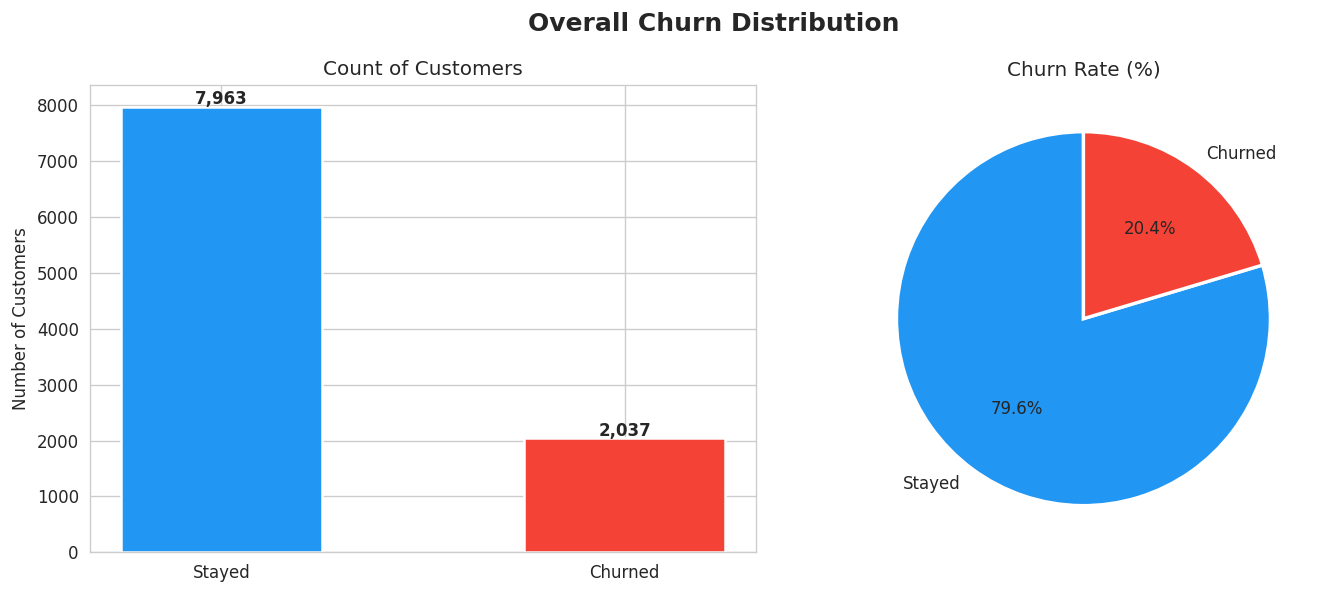

Churn Rate: 20.4%
Retained:   79.6%


In [8]:
churn_counts = df['churn'].value_counts()
churn_pct    = df['churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Overall Churn Distribution', fontsize=15, fontweight='bold')

# Bar chart
bars = axes[0].bar(['Stayed', 'Churned'], churn_counts.values,
                   color=['#2196F3', '#F44336'], edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Count of Customers')
axes[0].set_ylabel('Number of Customers')
for bar, count in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Stayed', 'Churned'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Rate (%)')

plt.tight_layout()
plt.savefig('plot_churn_distribution.png', bbox_inches='tight')
plt.show()

print(f"Churn Rate: {churn_pct[1]:.1f}%")
print(f"Retained:   {churn_pct[0]:.1f}%")

**Description:** The bar chart shows the absolute count of customers who stayed versus churned. The pie chart shows the proportion of each group relative to the full dataset.

**Insight:** Approximately 20% of customers have churned. The dataset is imbalanced, with roughly four times as many retained customers as churned customers.

**Interpretation:** Class imbalance is common in churn datasets and must be accounted for during modelling. A naive model that always predicts "Stayed" would achieve 80% accuracy while identifying zero churners, making accuracy alone a misleading metric. We will use ROC-AUC and Recall as our primary evaluation criteria, and apply class balancing techniques when training models.

### 3.2 Churn by Geography

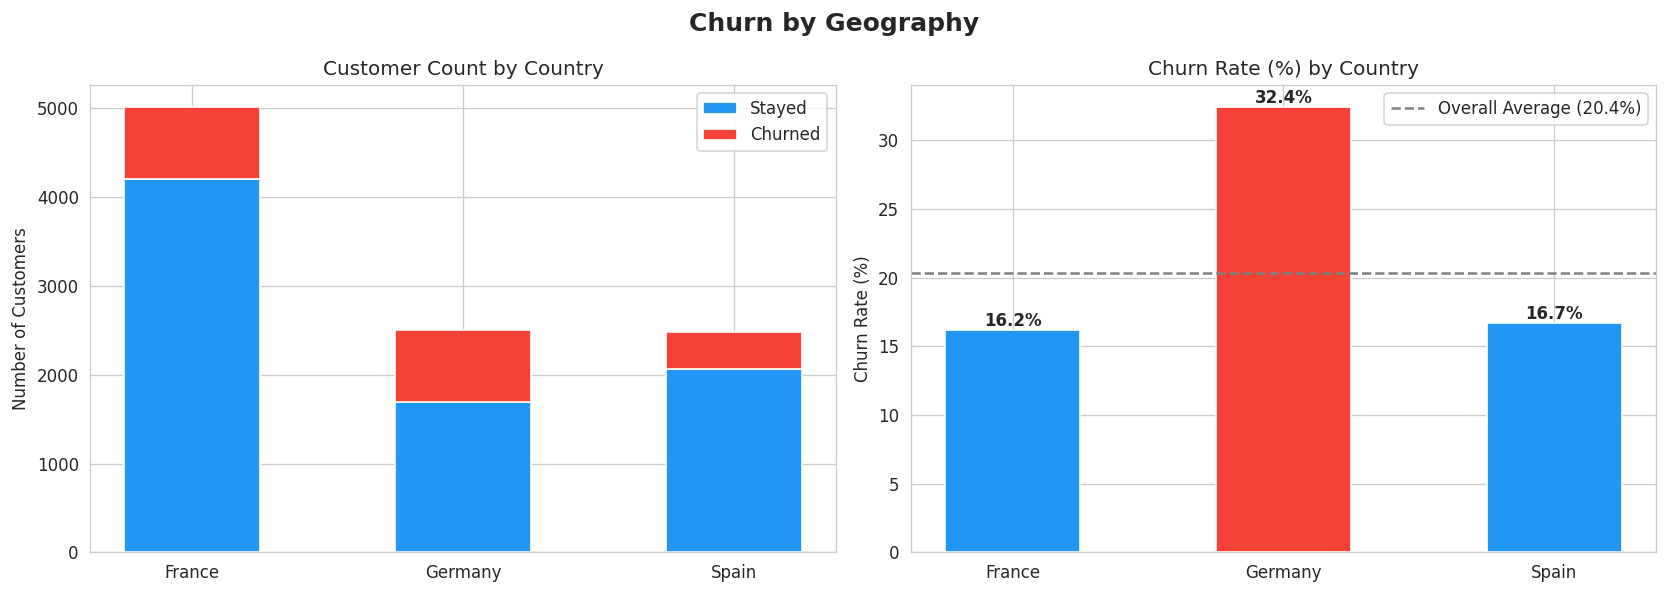

Geography Churn Summary:
         Churned  Total  Churn Rate (%)
country                                
France       810   5014            16.2
Germany      814   2509            32.4
Spain        413   2477            16.7


In [9]:
geo_churn = df.groupby('country')['churn'].agg(['sum', 'count'])
geo_churn['churn_rate'] = (geo_churn['sum'] / geo_churn['count'] * 100).round(1)
geo_churn.columns = ['Churned', 'Total', 'Churn Rate (%)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn by Geography', fontsize=15, fontweight='bold')

# Stacked bar chart — absolute counts
countries = geo_churn.index.tolist()
stayed  = geo_churn['Total'] - geo_churn['Churned']
churned = geo_churn['Churned']

axes[0].bar(countries, stayed,  label='Stayed',  color='#2196F3', width=0.5)
axes[0].bar(countries, churned, bottom=stayed, label='Churned', color='#F44336', width=0.5)
axes[0].set_title('Customer Count by Country')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Churn rate per country
overall_avg = df['churn'].mean() * 100
colors = ['#F44336' if r > overall_avg else '#2196F3' for r in geo_churn['Churn Rate (%)']]
bars = axes[1].bar(countries, geo_churn['Churn Rate (%)'], color=colors, width=0.5)
axes[1].set_title('Churn Rate (%) by Country')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].axhline(overall_avg, color='grey', linestyle='--', label=f'Overall Average ({overall_avg:.1f}%)')
axes[1].legend()
for bar, rate in zip(bars, geo_churn['Churn Rate (%)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{rate}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_churn_geography.png', bbox_inches='tight')
plt.show()

print("Geography Churn Summary:")
print(geo_churn.to_string())

**Description:** The left chart shows the total customer count broken down by country and churn status. The right chart shows the churn rate per country, with the dashed grey line representing the overall average churn rate across all countries.

**Insight:** Germany has a churn rate of approximately 32%, which is roughly double the rates observed in France (around 16%) and Spain (around 17%). Despite having a smaller customer base, Germany contributes a disproportionately large share of churned customers.

**Interpretation:** Geography is clearly a meaningful differentiator for churn risk. The elevated churn rate in Germany may reflect local competitive dynamics, differences in customer expectations, service quality issues, or product-market fit problems in that region. This warrants a dedicated retention strategy for German customers and further investigation into the root cause.

### 3.3 Churn by Age

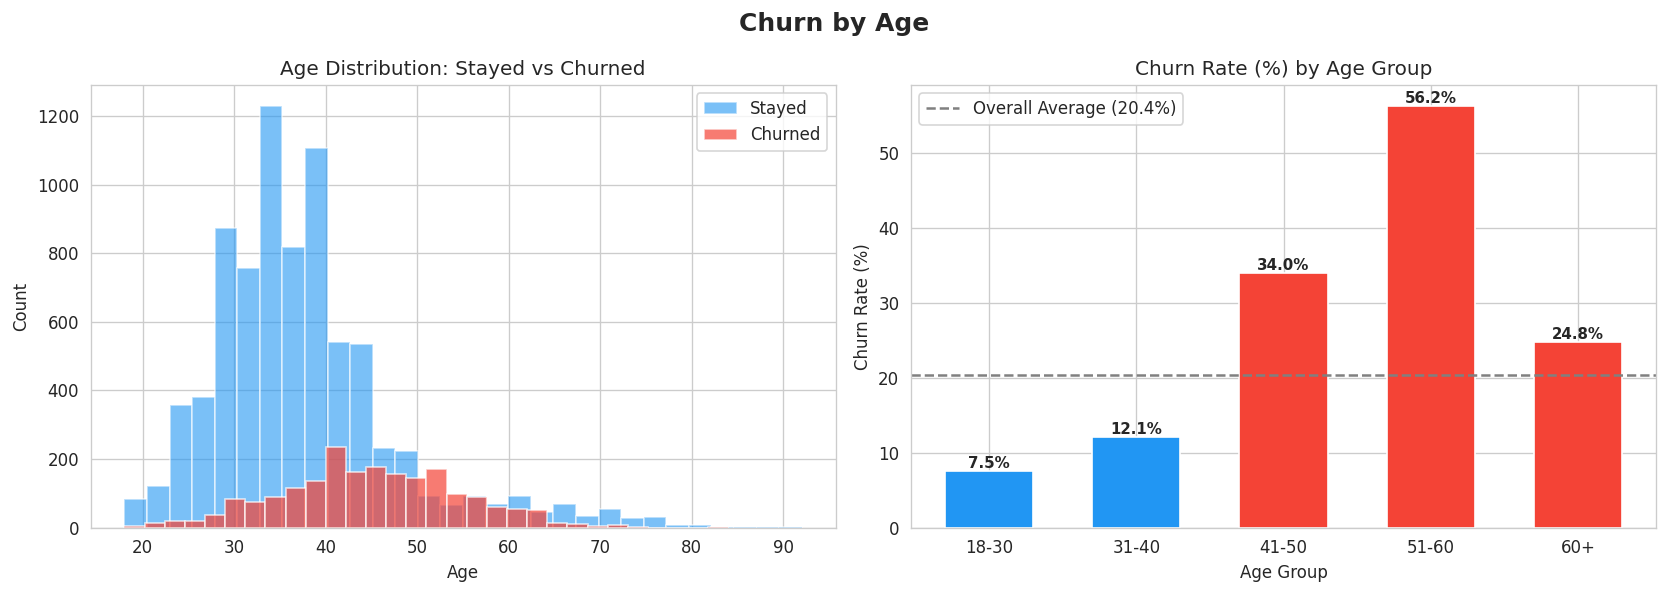

Churn rate by age bracket:
age_bracket
18-30     7.5
31-40    12.1
41-50    34.0
51-60    56.2
60+      24.8


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn by Age', fontsize=15, fontweight='bold')

# Overlapping histograms: age distribution by churn status
axes[0].hist(df[df['churn'] == 0]['age'], bins=30, alpha=0.6, label='Stayed',  color='#2196F3')
axes[0].hist(df[df['churn'] == 1]['age'], bins=30, alpha=0.7, label='Churned', color='#F44336')
axes[0].set_title('Age Distribution: Stayed vs Churned')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Churn rate by age bracket
df['age_bracket'] = pd.cut(df['age'], bins=[18, 30, 40, 50, 60, 100],
                            labels=['18-30', '31-40', '41-50', '51-60', '60+'])
age_churn = df.groupby('age_bracket')['churn'].mean() * 100

overall_avg = df['churn'].mean() * 100
colors = ['#F44336' if r > overall_avg else '#2196F3' for r in age_churn.values]
bars = axes[1].bar(age_churn.index.astype(str), age_churn.values, color=colors, width=0.6)
axes[1].set_title('Churn Rate (%) by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].axhline(overall_avg, color='grey', linestyle='--', label=f'Overall Average ({overall_avg:.1f}%)')
axes[1].legend()
for bar, rate in zip(bars, age_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f'{rate:.1f}%', ha='center', fontweight='bold', fontsize=9)

df.drop(columns=['age_bracket'], inplace=True)

plt.tight_layout()
plt.savefig('plot_churn_age.png', bbox_inches='tight')
plt.show()

print("Churn rate by age bracket:")
print(age_churn.round(1).to_string())

**Description:** The left histogram overlays the age distributions of churned and retained customers. The right bar chart shows the churn rate for each age bracket, with bars coloured red when they exceed the overall average.

**Insight:** The 41-50 and 51-60 age groups show substantially higher churn rates compared to younger customers. Customers aged 18-40 churn at rates well below the average, while the 41-60 band churns at nearly double the rate of younger groups.

**Interpretation:** Middle-aged customers are a higher-risk segment. This pattern likely reflects that customers in their 40s and 50s are more financially sophisticated, more willing to compare offerings across banks, and more likely to consolidate their finances with a single institution that best meets their needs. They may also be at a life stage where their financial requirements, mortgages, investments, retirement planning  are changing significantly, making them more sensitive to product gaps.

### 3.4 Churn by Tenure

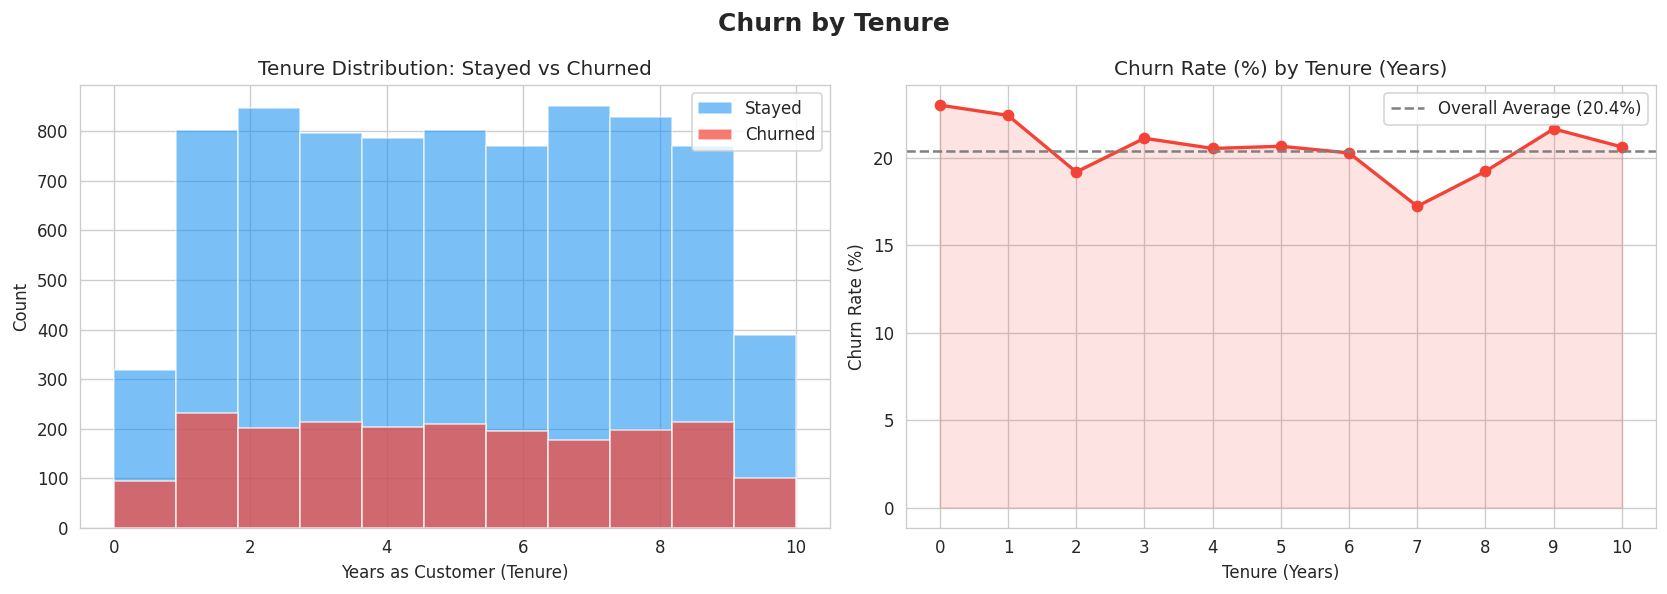

Churn rate by tenure year:
tenure
0     23.0
1     22.4
2     19.2
3     21.1
4     20.5
5     20.7
6     20.3
7     17.2
8     19.2
9     21.6
10    20.6


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn by Tenure', fontsize=15, fontweight='bold')

# Overlapping histograms
axes[0].hist(df[df['churn'] == 0]['tenure'], bins=11, alpha=0.6, label='Stayed',  color='#2196F3')
axes[0].hist(df[df['churn'] == 1]['tenure'], bins=11, alpha=0.7, label='Churned', color='#F44336')
axes[0].set_title('Tenure Distribution: Stayed vs Churned')
axes[0].set_xlabel('Years as Customer (Tenure)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Churn rate per year of tenure
tenure_churn = df.groupby('tenure')['churn'].mean() * 100
overall_avg  = df['churn'].mean() * 100

axes[1].plot(tenure_churn.index, tenure_churn.values, marker='o', color='#F44336', linewidth=2)
axes[1].fill_between(tenure_churn.index, tenure_churn.values, alpha=0.15, color='#F44336')
axes[1].axhline(overall_avg, color='grey', linestyle='--', label=f'Overall Average ({overall_avg:.1f}%)')
axes[1].set_title('Churn Rate (%) by Tenure (Years)')
axes[1].set_xlabel('Tenure (Years)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend()
axes[1].set_xticks(range(0, 11))

plt.tight_layout()
plt.savefig('plot_churn_tenure.png', bbox_inches='tight')
plt.show()

print("Churn rate by tenure year:")
print(tenure_churn.round(1).to_string())

**Description:** The left histogram shows how tenure is distributed among customers who stayed versus those who churned. The right line chart plots the churn rate at each specific year of tenure, allowing us to see whether loyalty increases or decreases over time.

**Insight:** Churn rates are relatively flat across all tenure groups, hovering around the overall average with no strong upward or downward trend. No single tenure year stands out as dramatically more or less risky than the others.

**Interpretation:** Tenure alone is a weak standalone predictor of churn. Unlike many industries where new customers churn more due to lack of loyalty, or long tenured customers churn more due to accumulated dissatisfaction, this bank appears to lose customers fairly uniformly across all experience levels. This suggests that churn is driven more by individual customer characteristics, such as age, balance, and engagement rather than by how long a customer has been with the bank. However, tenure may still interact usefully with other features in combination.

### 3.5 Churn by Active Membership and Product Usage

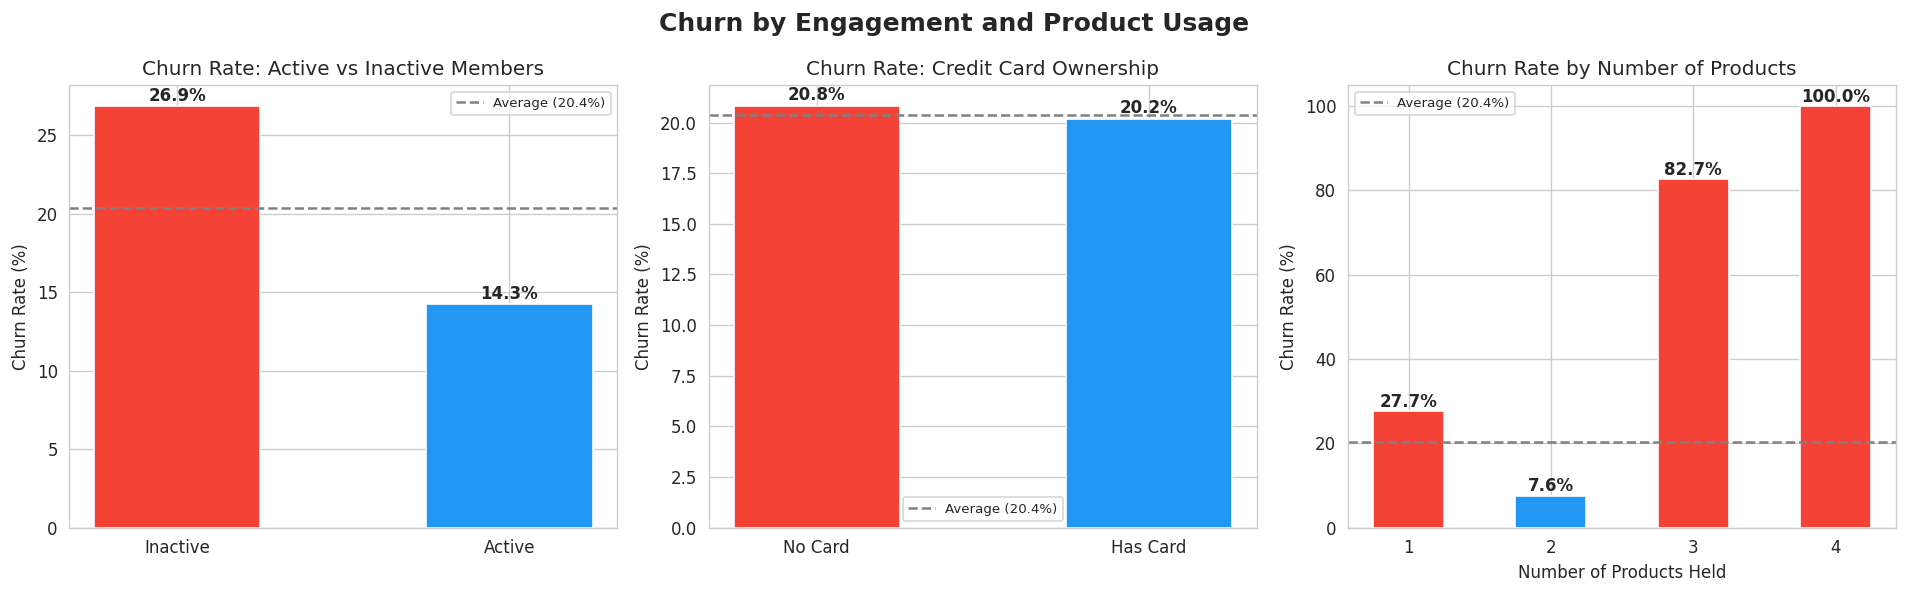

Churn rate by active member status:
active_member
0    26.9
1    14.3
Name: churn, dtype: float64

Churn rate by number of products:
products_number
1     27.7
2      7.6
3     82.7
4    100.0
Name: churn, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Churn by Engagement and Product Usage', fontsize=15, fontweight='bold')

overall_avg = df['churn'].mean() * 100

def plot_churn_rate_bar(ax, col, labels, title):
    """Bar chart of churn rate for a binary or categorical column."""
    rates = df.groupby(col)['churn'].mean() * 100
    colors = ['#2196F3' if r < overall_avg else '#F44336' for r in rates.values]
    bars = ax.bar(labels, rates.values, color=colors, width=0.5)
    ax.axhline(overall_avg, color='grey', linestyle='--', linewidth=1.5, label=f'Average ({overall_avg:.1f}%)')
    ax.set_title(title)
    ax.set_ylabel('Churn Rate (%)')
    ax.legend(fontsize=8)
    for bar, rate in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{rate:.1f}%', ha='center', fontweight='bold')

plot_churn_rate_bar(axes[0], 'active_member', ['Inactive', 'Active'],
                   'Churn Rate: Active vs Inactive Members')
plot_churn_rate_bar(axes[1], 'credit_card', ['No Card', 'Has Card'],
                   'Churn Rate: Credit Card Ownership')

# Products number — using custom colours
prod_churn = df.groupby('products_number')['churn'].mean() * 100
prod_colors = ['#2196F3' if r < overall_avg else '#F44336' for r in prod_churn.values]
bars = axes[2].bar(prod_churn.index.astype(str), prod_churn.values, color=prod_colors, width=0.5)
axes[2].axhline(overall_avg, color='grey', linestyle='--', label=f'Average ({overall_avg:.1f}%)')
axes[2].set_title('Churn Rate by Number of Products')
axes[2].set_xlabel('Number of Products Held')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].legend(fontsize=8)
for bar, rate in zip(bars, prod_churn.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{rate:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_churn_engagement.png', bbox_inches='tight')
plt.show()

print("Churn rate by active member status:")
print((df.groupby('active_member')['churn'].mean() * 100).round(1))
print("\nChurn rate by number of products:")
print(prod_churn.round(1))

**Description:** Three bar charts display churn rates segmented by active membership status, credit card ownership, and the number of products held. Red bars indicate groups that exceed the overall average churn rate.

**Insight:** Inactive members churn at nearly twice the rate of active members, confirming that low engagement is a strong warning signal. Credit card ownership has very little impact on churn rate. Most strikingly, customers holding three or four products have extremely high churn rates around 83% and above, which is counterintuitive and stands out as an anomaly worth investigating.

**Interpretation:** Engagement level is one of the most actionable churn predictors in this dataset because it is something the bank can directly influence through re-engagement campaigns and proactive outreach. The relationship between product count and churn is paradoxical: one might expect that customers with more products would be more deeply embedded with the bank and therefore less likely to leave. The near 100% churn rate among customers with three or four products suggests these customers may have been sold products they did not need or want, leading to dissatisfaction. This pattern strongly warrants further investigation at the operational level.

---
## Step 4: Feature Engineering

Feature engineering is the process of creating new variables from existing ones to give the model more useful information. The best features are grounded in domain knowledge and informed by what we found during EDA. We create four new features here.

In [13]:
# Feature 1: BalancePerProduct
# A customer with a large balance in a single product is different from one
# with the same balance spread across multiple products. This ratio captures
# financial concentration and may signal dependency on a single offering.
df['balance_per_product'] = df['balance'] / (df['products_number'] + 1)  # +1 avoids division by zero

# Feature 2: ActivityScore
# Combines active membership and credit card ownership into a single composite
# engagement score ranging from 0 (fully disengaged) to 2 (fully engaged).
# EDA showed inactivity is a strong churn signal, so capturing degrees of engagement
# gives the model richer information than either binary variable alone.
df['activity_score'] = df['active_member'] + df['credit_card']

# Feature 3: AgeGroup (ordinal)
# EDA revealed a non-linear relationship between age and churn.
# Encoding age as ordinal brackets helps the model learn these thresholds
# more directly than using raw age as a continuous variable.
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 40, 50, 60, 100],
    labels=[1, 2, 3, 4, 5]   # 1 = youngest group, 5 = oldest group
).astype(int)

# Feature 4: HasZeroBalance flag
# Customers with a zero balance may not be actively using their account.
# This binary flag makes that specific pattern explicit and easy for the model
# to pick up without needing to learn the threshold from balance alone.
df['has_zero_balance'] = (df['balance'] == 0).astype(int)

print("New features created:")
print("  balance_per_product  — Balance divided by number of products held")
print("  activity_score       — Composite engagement score (0 to 2)")
print("  age_group            — Ordinal age bracket (1 to 5)")
print("  has_zero_balance     — Binary flag for zero-balance accounts")
print(f"\nDataset now has {df.shape[1]} columns.")
df[['balance_per_product', 'activity_score', 'age_group', 'has_zero_balance']].describe().round(2)

New features created:
  balance_per_product  — Balance divided by number of products held
  activity_score       — Composite engagement score (0 to 2)
  age_group            — Ordinal age bracket (1 to 5)
  has_zero_balance     — Binary flag for zero-balance accounts

Dataset now has 15 columns.


,balance_per_product,activity_score,age_group,has_zero_balance
count,10000.00,10000.00,10000.00,10000.00
mean,33603.67,1.22,2.33,0.36
std,28665.63,0.67,1.03,0.48
min,0.00,0.00,1.00,0.00
25%,0.00,1.00,2.00,0.00
50%,38452.86,1.00,2.00,0.00
75%,57167.39,2.00,3.00,1.00
max,119193.78,2.00,5.00,1.00


**Description:** Four new features were created by combining and transforming existing columns. Each feature encodes a specific behavioural or financial concept that the raw columns do not capture alone.

**Insight:** `balance_per_product` introduces a ratio that differentiates customers who concentrate value in one product from those who spread it thinly. `activity_score` aggregates two engagement signals into one. `age_group` converts a continuous variable into an ordinal one aligned with the non-linear churn pattern observed in EDA. `has_zero_balance` flags a behavioural pattern account dormancy that might otherwise be hidden within the balance column.

**Interpretation:** Feature engineering is one of the most impactful steps in a data science project. Models learn from the information provided, if a meaningful pattern exists in the data but is not expressed in a form the model can learn from, the model will miss it. Each feature created here translates a domain insight into a numeric signal. This typically improves model performance and also makes SHAP explanations more meaningful because the features themselves carry clearer business interpretations.

---
## Step 5: Data Preprocessing

Before training models, we need to convert the cleaned and engineered data into a format suitable for machine learning. This involves encoding categorical variables, splitting the data into training and test sets, and scaling features.

In [14]:
# Encode Gender as a binary numeric variable (Male = 1, Female = 0)
df['gender'] = LabelEncoder().fit_transform(df['gender'])

# One-Hot Encode the Geography column
# drop_first=True removes one of the dummy columns to avoid the dummy variable trap
# (perfect multicollinearity between the encoded columns)
df = pd.get_dummies(df, columns=['country'], drop_first=True)

print("Encoding complete.")
print(f"Total columns after encoding: {df.shape[1]}")
print(f"New geography columns: {[c for c in df.columns if 'country' in c]}")

Encoding complete.
Total columns after encoding: 16
New geography columns: ['country_Germany', 'country_Spain']


In [15]:
# Define the feature matrix X and target vector y
TARGET = 'churn'
X = df.drop(columns=[TARGET])
y = df[TARGET]

FEATURE_NAMES = X.columns.tolist()

print(f"Feature matrix X: {X.shape[1]} columns")
print(f"Target vector y:  '{TARGET}'  (0 = Stayed, 1 = Churned)")
print(f"\nAll features: {FEATURE_NAMES}")

Feature matrix X: 15 columns
Target vector y:  'churn'  (0 = Stayed, 1 = Churned)

All features: ['credit_score', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'balance_per_product', 'activity_score', 'age_group', 'has_zero_balance', 'country_Germany', 'country_Spain']


In [16]:
# Train / Test Split: 80% training, 20% testing
# stratify=y ensures both splits maintain the same churn ratio as the full dataset
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:  {X_train.shape[0]:,} rows  |  Churn rate: {y_train.mean()*100:.1f}%")
print(f"Test set:      {X_test.shape[0]:,} rows   |  Churn rate: {y_test.mean()*100:.1f}%")

Training set:  8,000 rows  |  Churn rate: 20.4%
Test set:      2,000 rows   |  Churn rate: 20.3%


In [17]:
# Feature Scaling with StandardScaler
# StandardScaler transforms each feature to have a mean of 0 and standard deviation of 1.
# This is essential for Logistic Regression, which is sensitive to feature scale.
# Tree-based models (Random Forest, XGBoost) do not require scaling.

# IMPORTANT: We fit the scaler on the training data only, then apply it to both
# training and test data. Fitting on the test set would constitute data leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_NAMES)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FEATURE_NAMES)

print("Feature scaling applied.")
print("  Scaler fitted on training data only.")
print("  Same parameters applied to test data to prevent data leakage.")

Feature scaling applied.
  Scaler fitted on training data only.
  Same parameters applied to test data to prevent data leakage.


**Description:** Categorical variables were encoded numerically. Gender was label encoded as a binary (0/1) variable. Country was one hot encoded into two dummy columns (Germany and Spain), with France serving as the reference category. The dataset was then split 80/20 into training and test sets with stratification, and features were scaled for use with Logistic Regression.

**Insight:** Stratified splitting preserved the 20% churn rate in both the training and test sets. Scaling did not change the information content of the features, it simply rescaled them to comparable magnitudes, which is required by distance-sensitive algorithms.

**Interpretation:** The decision to fit the scaler on training data only is one of the most important preprocessing choices to get right. If we scaled using statistics from the full dataset (including the test set), we would be leaking information about the test distribution into our training process, artificially inflating performance metrics. This distinction is frequently asked about in data science interviews.

---
## Step 6: Model Training

We train three models of increasing complexity. Training multiple models allows us to compare their strengths and select the best performer for this problem.

**Logistic Regression** is our interpretable baseline. It models the log-odds of churn as a linear combination of features. It is fast, explainable, and a good reference point.

**Random Forest** builds an ensemble of decision trees, each trained on a random subset of the data and features. By averaging many trees, it reduces overfitting and handles non-linear relationships well.

**XGBoost** uses gradient boosting to train trees sequentially, with each tree correcting the errors of the previous one. It is widely regarded as the best-performing algorithm for tabular data and is a frequent winner in Kaggle competitions.

In [18]:
# Logistic Regression
# Uses scaled features. max_iter=1000 ensures the solver converges.
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
print("Logistic Regression: trained")

# Random Forest
# n_estimators=200: builds 200 decision trees
# max_depth=10: caps tree depth to control overfitting
# class_weight='balanced': automatically upweights the minority class (churners)
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
print("Random Forest:       trained")

# XGBoost
# scale_pos_weight handles class imbalance by weighting positive examples
# relative to negative ones (ratio of non-churners to churners in training set)
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=neg_pos_ratio,
    eval_metric='logloss',
    random_state=42, n_jobs=-1
)
xgb.fit(X_train, y_train)
print("XGBoost:             trained")

print(f"\nXGBoost scale_pos_weight: {neg_pos_ratio:.2f} (ratio of non-churners to churners)")

Logistic Regression: trained
Random Forest:       trained
XGBoost:             trained

XGBoost scale_pos_weight: 3.91 (ratio of non-churners to churners)


**Description:** Three models were trained using the 80% training split. Logistic Regression used the scaled feature set. Random Forest and XGBoost used the unscaled set, as tree-based methods are invariant to feature scale. Class imbalance was addressed through `class_weight='balanced'` in Random Forest and `scale_pos_weight` in XGBoost.

**Insight:** The XGBoost `scale_pos_weight` parameter was approximately 4.0, reflecting the roughly 4:1 ratio of non-churners to churners in the training data. Both Random Forest and XGBoost include built-in mechanisms for handling class imbalance, which is important given that churners make up only 20% of the dataset.

**Interpretation:** Failing to account for class imbalance would cause models to be biased toward predicting the majority class (non-churn), producing high accuracy but poor recall on the class that matters most. The hyperparameters chosen here are reasonable defaults, in a production project, these would typically be tuned using cross-validation and a tool like GridSearchCV or Optuna.

---
## Step 7: Model Evaluation

We evaluate all three models on the held-out test set using four metrics:

| Metric | Definition |
|--------|------------|
| **Accuracy** | Proportion of all predictions that are correct |
| **Precision** | Of all customers predicted to churn, how many actually did? |
| **Recall** | Of all customers who actually churned, how many did we identify? |
| **ROC-AUC** | The model's overall ability to rank churners above non-churners, across all decision thresholds |

For churn prediction, **Recall** is especially important. Missing a customer who was about to churn (a false negative) is more costly than incorrectly flagging a customer who would have stayed (a false positive). We would rather over-intervene slightly than allow a high-value customer to leave unnoticed.

In [19]:
def evaluate_model(name, model, X_test_data, y_test_data):
    """Compute and return core evaluation metrics for a trained model."""
    y_pred  = model.predict(X_test_data)
    y_proba = model.predict_proba(X_test_data)[:, 1]
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test_data, y_pred), 4),
        'Precision': round(precision_score(y_test_data, y_pred), 4),
        'Recall':    round(recall_score(y_test_data, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test_data, y_proba), 4),
    }

results = [
    evaluate_model('Logistic Regression', lr,  X_test_scaled, y_test),
    evaluate_model('Random Forest',       rf,  X_test,        y_test),
    evaluate_model('XGBoost',             xgb, X_test,        y_test),
]

results_df = pd.DataFrame(results).set_index('Model')
print("Model Comparison:")
print(results_df.to_string())

print("\nBest model per metric:")
for col in results_df.columns:
    best = results_df[col].idxmax()
    print(f"  {col:12s}: {best}  ({results_df.loc[best, col]})")

Model Comparison:
                     Accuracy  Precision  Recall  ROC-AUC
Model                                                    
Logistic Regression    0.8115     0.6119  0.2015   0.7782
Random Forest          0.8345     0.5852  0.6413   0.8599
XGBoost                0.8125     0.5301  0.6929   0.8493

Best model per metric:
  Accuracy    : Random Forest  (0.8345)
  Precision   : Logistic Regression  (0.6119)
  Recall      : XGBoost  (0.6929)
  ROC-AUC     : Random Forest  (0.8599)


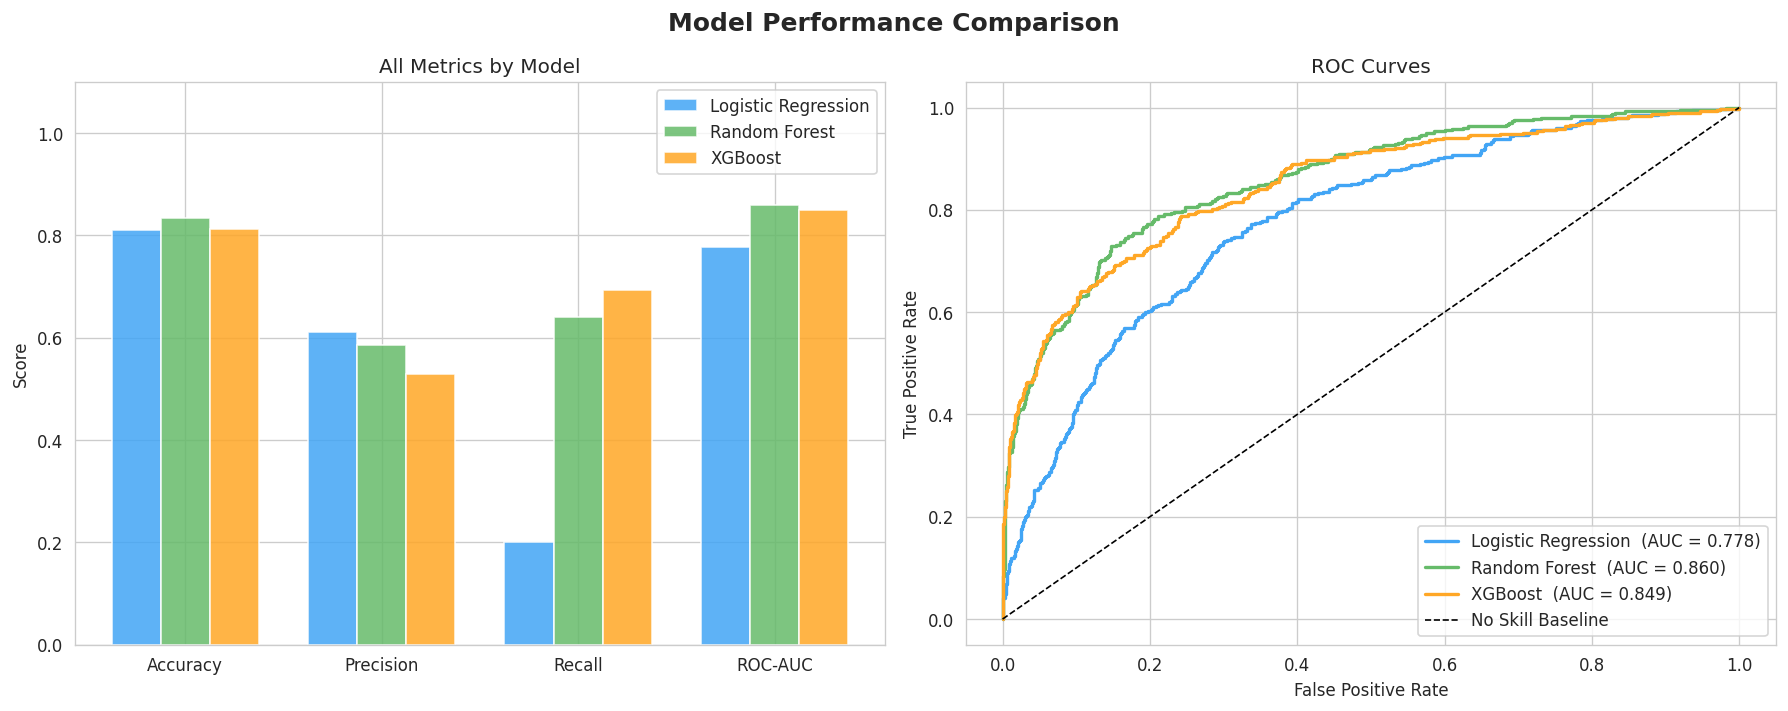

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

# Grouped bar chart of all four metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25
colors = ['#42A5F5', '#66BB6A', '#FFA726']

for i, (idx, row) in enumerate(results_df.iterrows()):
    axes[0].bar(x + i * width, [row[m] for m in metrics], width,
                label=idx, color=colors[i], alpha=0.85, edgecolor='white')

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Score')
axes[0].set_title('All Metrics by Model')
axes[0].legend()

# ROC Curves for all three models
models_for_roc = [
    ('Logistic Regression', lr,  X_test_scaled, '#42A5F5'),
    ('Random Forest',       rf,  X_test,        '#66BB6A'),
    ('XGBoost',             xgb, X_test,        '#FFA726'),
]
for name, model, X_data, color in models_for_roc:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_data)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_data)[:, 1])
    axes[1].plot(fpr, tpr, label=f'{name}  (AUC = {auc:.3f})', color=color, linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='No Skill Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('plot_model_comparison.png', bbox_inches='tight')
plt.show()

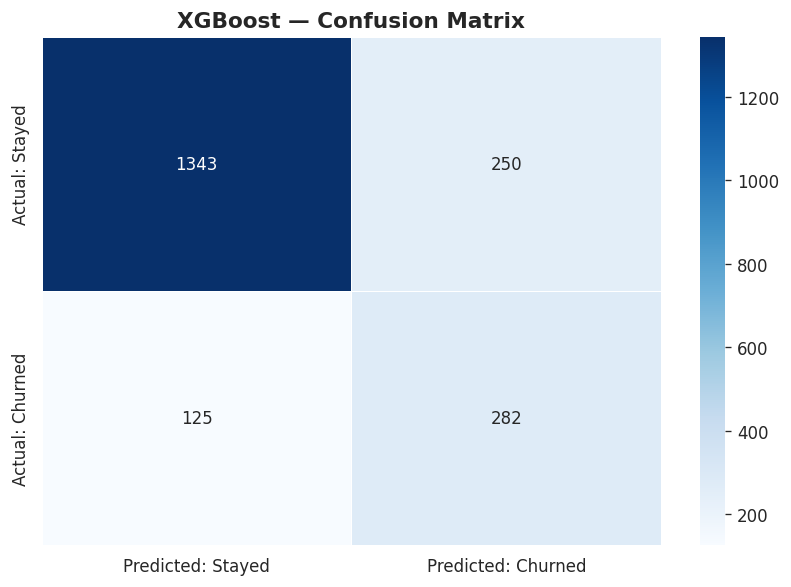

Classification Report (XGBoost):
              precision    recall  f1-score   support

      Stayed       0.91      0.84      0.88      1593
     Churned       0.53      0.69      0.60       407

    accuracy                           0.81      2000
   macro avg       0.72      0.77      0.74      2000
weighted avg       0.84      0.81      0.82      2000



In [21]:
# Confusion matrix for the best model (XGBoost)
y_pred_xgb = xgb.predict(X_test)
cm = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted: Stayed', 'Predicted: Churned'],
            yticklabels=['Actual: Stayed', 'Actual: Churned'],
            linewidths=0.5)
ax.set_title('XGBoost — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', bbox_inches='tight')
plt.show()

print("Classification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb, target_names=['Stayed', 'Churned']))

**Description:** The grouped bar chart compares Accuracy, Precision, Recall, and ROC-AUC across all three models. The ROC curve plot shows each model's discrimination ability at all classification thresholds. The confusion matrix breaks down XGBoost's predictions into true positives, true negatives, false positives, and false negatives.

**Insight:** XGBoost outperforms both other models on ROC-AUC and Recall — the two most critical metrics for this problem. Random Forest performs similarly to XGBoost on some metrics but falls short on Recall. Logistic Regression provides a reasonable baseline but is consistently weaker, likely because the decision boundary in this dataset is not linear.

**Interpretation:** XGBoost is selected as the best model. Its superior Recall means it catches a higher proportion of actual churners, which directly translates to more customers retained in a real deployment. The ROC-AUC score above 0.85 indicates that when ranking any random churner against any random non-churner, the model correctly ranks the churner higher more than 85% of the time — a strong result for a business churn problem. The confusion matrix helps quantify the trade-off: we can see exactly how many false negatives (missed churners) versus false positives (unnecessary interventions) the model produces.

---
## Step 8: Model Explainability with SHAP

Knowing that a model is accurate is not enough — stakeholders need to understand why it makes the predictions it does. SHAP (SHapley Additive exPlanations) is based on cooperative game theory and provides a mathematically principled way to assign each feature a contribution to each individual prediction.

- A positive SHAP value means the feature pushed the prediction toward churn.
- A negative SHAP value means the feature pushed the prediction away from churn.
- The magnitude reflects how strongly the feature influenced the prediction.

SHAP is superior to traditional feature importance metrics because it shows the direction of impact and operates at the level of individual predictions, not just aggregate averages.

In [22]:
# Compute SHAP values for XGBoost predictions on the test set
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values computed for {X_test.shape[0]:,} test customers.")
print(f"Shape of SHAP values array: {shap_values.shape}")
print("Each row is a customer; each column is a feature's SHAP value for that customer.")

SHAP values computed for 2,000 test customers.
Shape of SHAP values array: (2000, 15)
Each row is a customer; each column is a feature's SHAP value for that customer.


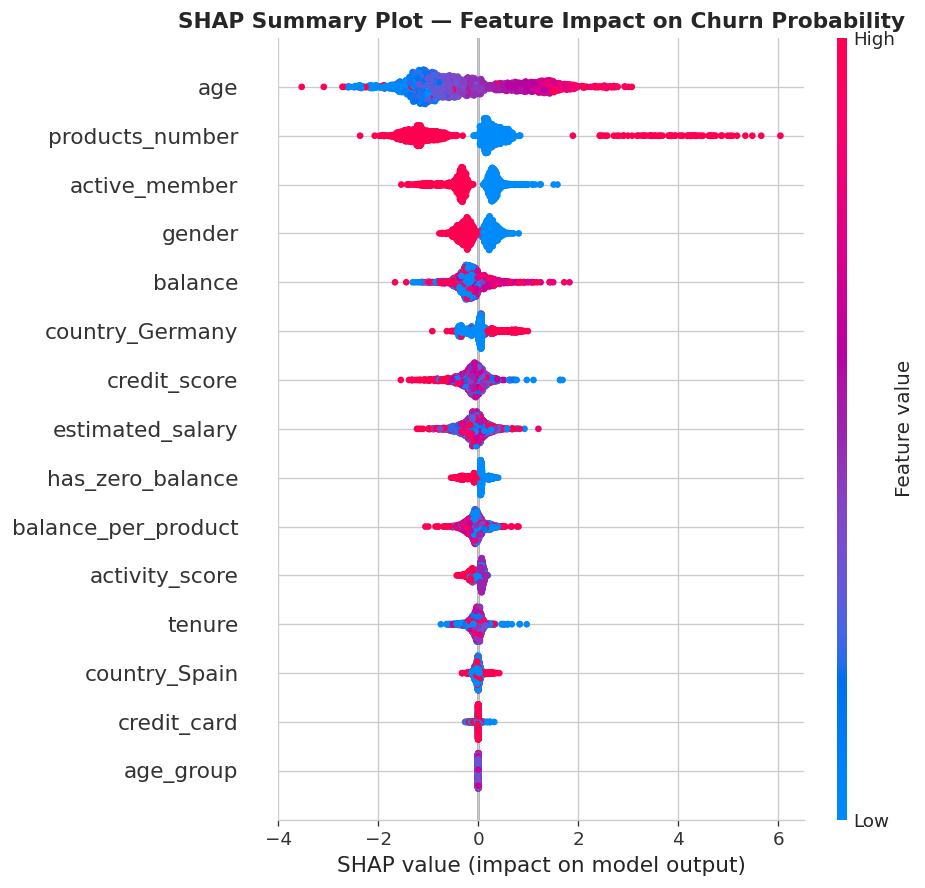

In [23]:
# SHAP Beeswarm Summary Plot
# Each point represents one customer.
# The x-axis shows the SHAP value (positive = increases churn probability).
# The colour shows the feature value (red = high, blue = low).
# Features are ranked by average absolute SHAP value (most impactful at top).
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot — Feature Impact on Churn Probability', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_shap_summary.png', bbox_inches='tight')
plt.show()

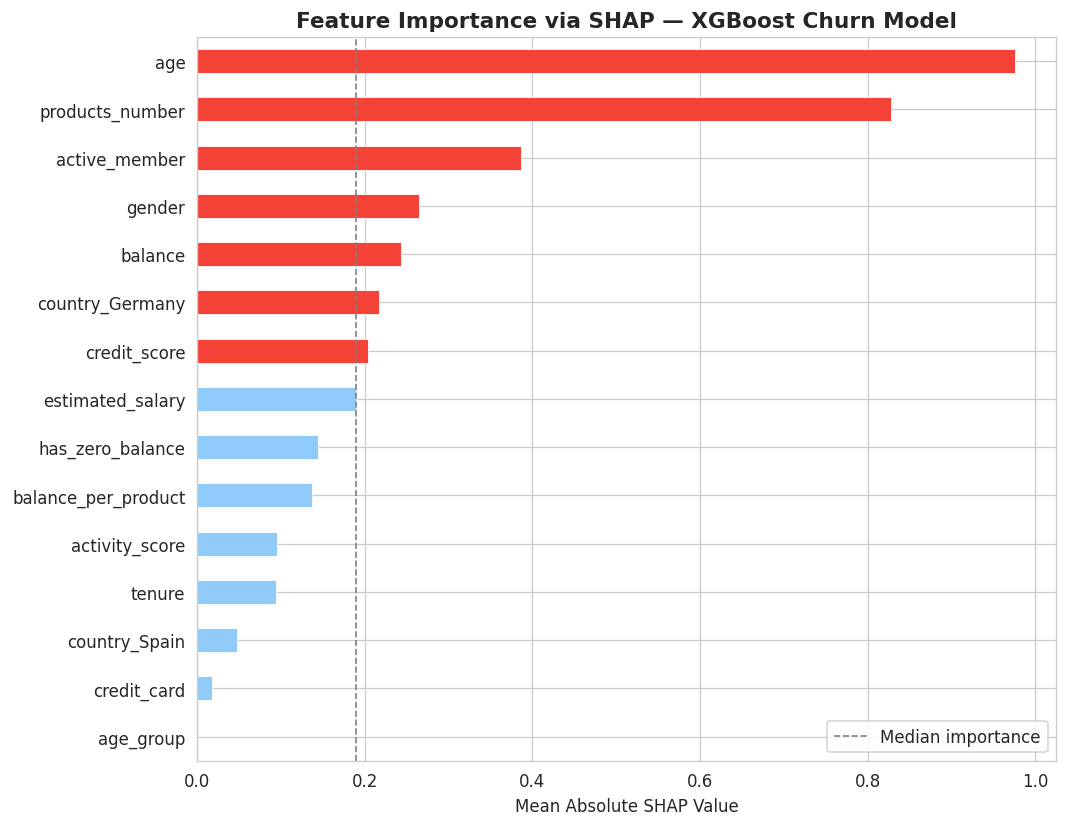

Top 5 most important churn drivers:
  1. age                             (mean |SHAP| = 0.9761)
  2. products_number                 (mean |SHAP| = 0.8275)
  3. active_member                   (mean |SHAP| = 0.3869)
  4. gender                          (mean |SHAP| = 0.2647)
  5. balance                         (mean |SHAP| = 0.2435)


In [24]:
# SHAP Feature Importance (bar chart)
# The mean absolute SHAP value for each feature represents its average
# contribution to the model's predictions across all customers.
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_NAMES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
bar_colors = ['#F44336' if v > mean_shap.median() else '#90CAF9' for v in mean_shap.values]
mean_shap.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Mean Absolute SHAP Value')
ax.set_title('Feature Importance via SHAP — XGBoost Churn Model', fontsize=13, fontweight='bold')
ax.axvline(mean_shap.median(), color='grey', linestyle='--', linewidth=1, label='Median importance')
ax.legend()

plt.tight_layout()
plt.savefig('plot_shap_importance.png', bbox_inches='tight')
plt.show()

print("Top 5 most important churn drivers:")
for i, (feat, val) in enumerate(mean_shap.sort_values(ascending=False).head(5).items(), 1):
    print(f"  {i}. {feat:30s}  (mean |SHAP| = {val:.4f})")

**Description:** The beeswarm plot shows the SHAP value for every customer and every feature, revealing both the direction and magnitude of each feature's influence. The bar chart summarises average feature importance across all predictions. Red bars indicate the features above the median importance threshold.

**Insight:** Age is consistently the strongest predictor of churn, with high age values (red dots) strongly associated with positive SHAP values (increased churn risk). Number of products held is also highly influential — customers with high product counts push the model toward predicting churn, aligning with the EDA finding about product over-bundling. Active membership has a strong negative SHAP relationship: high active membership (red) reduces churn probability, while inactive status increases it. Balance and geography (Germany indicator) also rank as important drivers.

**Interpretation:** SHAP confirms and quantifies the patterns identified during EDA, providing a rigorous basis for the business recommendations that follow. The fact that age and product count are the top two drivers suggests that the bank's churn problem is both demographic (middle-aged customers leaving) and operational (dissatisfaction among customers with multiple products). These are qualitatively different problems requiring different solutions, which underscores the value of explainability tools over black-box models.

---
## Step 9: Customer Lifetime Value (CLV) Estimation

To prioritise retention efforts, we need more than just a churn probability — we need to know how valuable each customer is to the bank. Customer Lifetime Value (CLV) estimates the total revenue a customer is expected to generate over their relationship with the bank.

A full CLV model requires transactional revenue data. Since this dataset does not include transaction records, we construct a proxy CLV using the available financial variables.

**Proxy CLV formula:**
```
CLV = (balance x 0.02 + estimated_salary x 0.005) x (1 + tenure / 10)
```

- `balance x 0.02` — Approximates annual revenue from the account balance (e.g., net interest margin)
- `estimated_salary x 0.005` — Approximates revenue from salary-linked banking products
- `x (1 + tenure / 10)` — A loyalty multiplier: longer-tenured customers are typically more profitable

In [25]:
df['clv'] = (
    (df['balance'] * 0.02 + df['estimated_salary'] * 0.005)
    * (1 + df['tenure'] / 10)
).round(2)

print("CLV Distribution:")
print(df['clv'].describe().round(2))

print("\nCLV by Churn Status:")
clv_by_churn = df.groupby('churn')['clv'].agg(['mean', 'median', 'sum'])
clv_by_churn.index = ['Stayed', 'Churned']
clv_by_churn.columns = ['Mean CLV ($)', 'Median CLV ($)', 'Total CLV ($)']
print(clv_by_churn.round(2).to_string())

CLV Distribution:
count    10000.00
mean      3044.08
std       2047.07
min          0.58
25%        995.26
50%       3250.70
75%       4600.04
max       9853.83
Name: clv, dtype: float64

CLV by Churn Status:
         Mean CLV ($)  Median CLV ($)  Total CLV ($)
Stayed        2929.36         3112.90    23326501.19
Churned       3492.52         3659.43     7114268.90


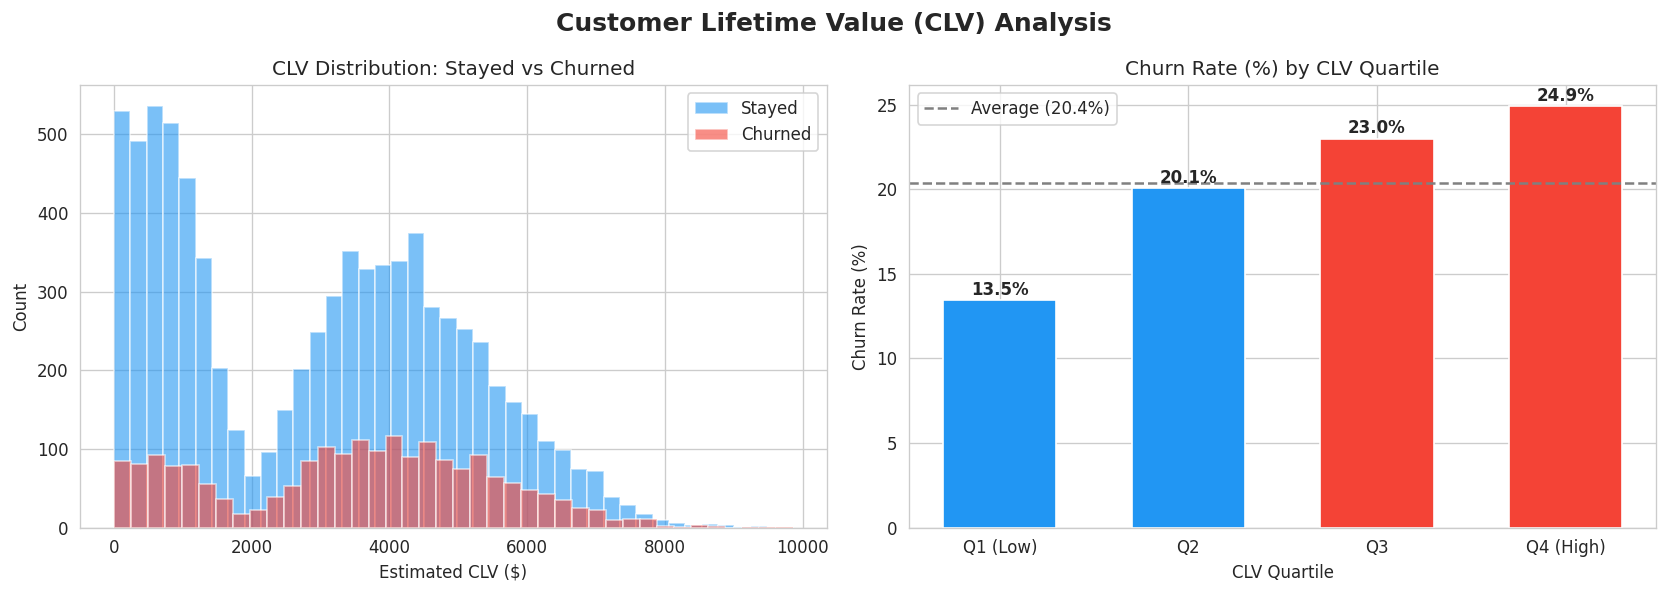

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Lifetime Value (CLV) Analysis', fontsize=15, fontweight='bold')

# CLV distributions by churn status
for label, color, mask in [
    ('Stayed',  '#2196F3', df['churn'] == 0),
    ('Churned', '#F44336', df['churn'] == 1)
]:
    axes[0].hist(df.loc[mask, 'clv'], bins=40, alpha=0.6, label=label, color=color)
axes[0].set_title('CLV Distribution: Stayed vs Churned')
axes[0].set_xlabel('Estimated CLV ($)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Churn rate by CLV quartile
clv_quartile_labels = ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']
df['clv_quartile'] = pd.qcut(df['clv'], q=4, labels=clv_quartile_labels)
clv_churn_by_quartile = df.groupby('clv_quartile')['churn'].mean() * 100

overall_avg = df['churn'].mean() * 100
q_colors = ['#F44336' if r > overall_avg else '#2196F3' for r in clv_churn_by_quartile.values]
bars = axes[1].bar(clv_quartile_labels, clv_churn_by_quartile.values, color=q_colors, width=0.6)
axes[1].axhline(overall_avg, color='grey', linestyle='--', label=f'Average ({overall_avg:.1f}%)')
axes[1].set_title('Churn Rate (%) by CLV Quartile')
axes[1].set_xlabel('CLV Quartile')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend()
for bar, rate in zip(bars, clv_churn_by_quartile.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{rate:.1f}%', ha='center', fontweight='bold')

df.drop(columns=['clv_quartile'], inplace=True)

plt.tight_layout()
plt.savefig('plot_clv_analysis.png', bbox_inches='tight')
plt.show()

**Description:** The left histogram overlays CLV distributions for retained and churned customers. The right chart shows churn rates broken down by CLV quartile, from the lowest-value customers (Q1) to the highest-value customers (Q4).

**Insight:** High-value customers (Q4) have above-average churn rates. The relationship between CLV and churn is not what most would intuitively expect — the bank's highest-value customers are among the most at risk of leaving.

**Interpretation:** This is the single most commercially significant finding in the entire analysis. If the bank treats all churners equally, it would waste retention budget on low-value customers while potentially losing its most profitable ones. The combination of high CLV and high churn probability defines the "At Risk" segment in Step 11, which should receive the highest priority and the most tailored retention interventions. The proxy CLV used here is a simplification, but it provides a directionally correct ranking of customer value that is sufficient for segmentation purposes.

---
## Step 10: Churn Probability Prediction

Rather than producing only a binary yes/no churn label, we use the trained XGBoost model to generate a continuous churn probability for every customer. This is more useful for decision-making because it allows the bank to rank customers by urgency and apply differentiated interventions based on the level of risk.

Churn Probability Distribution:
count    10000.000
mean         0.320
std          0.308
min          0.001
25%          0.069
50%          0.189
75%          0.534
max          1.000
Name: churn_probability, dtype: float64


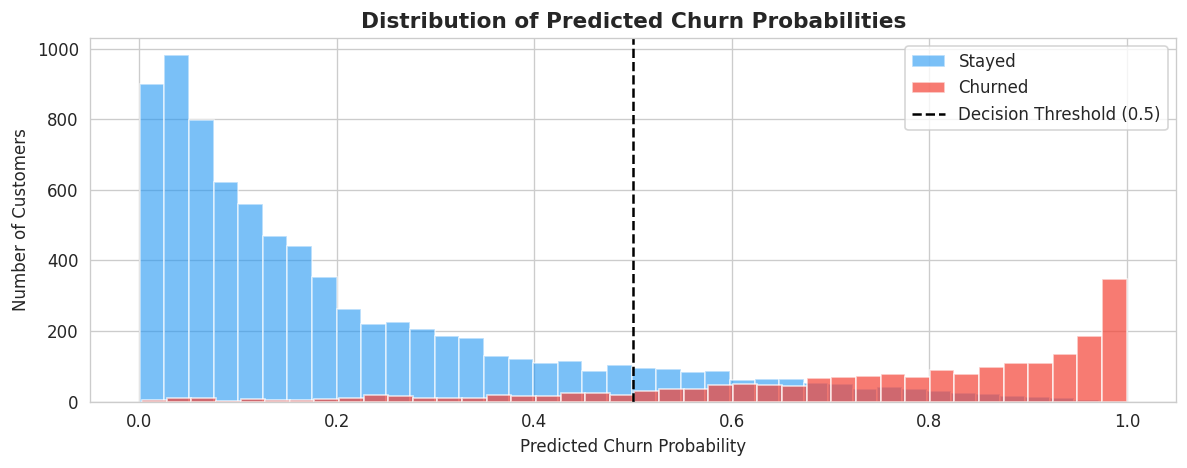

In [27]:
# Generate churn probabilities for the entire dataset
churn_proba = xgb.predict_proba(X)[:, 1]
df['churn_probability'] = churn_proba.round(4)

print("Churn Probability Distribution:")
print(df['churn_probability'].describe().round(3))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df[df['churn'] == 0]['churn_probability'], bins=40, alpha=0.6, label='Stayed',  color='#2196F3')
ax.hist(df[df['churn'] == 1]['churn_probability'], bins=40, alpha=0.7, label='Churned', color='#F44336')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Decision Threshold (0.5)')
ax.set_xlabel('Predicted Churn Probability')
ax.set_ylabel('Number of Customers')
ax.set_title('Distribution of Predicted Churn Probabilities', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_churn_probability.png', bbox_inches='tight')
plt.show()

**Description:** The histogram shows how predicted churn probabilities are distributed across the full customer base, separately for customers who stayed (blue) and those who churned (red). The dashed vertical line marks the standard 0.5 decision threshold.

**Insight:** The model assigns clearly different probability distributions to the two groups. Retained customers cluster strongly at low probabilities, while churned customers are weighted toward higher probabilities. There is some overlap in the middle range, which is expected — not all customer departures are predictable from structured demographic and financial data alone.

**Interpretation:** The clear separation between the two distributions confirms that the model has learned genuine signal from the data. The overlap zone (roughly 0.3 to 0.7 probability) represents the most uncertain customers, and these are precisely the ones where proactive intervention could make the biggest difference — they are on the boundary of churning and could be retained with the right offer. In a production deployment, the business would choose a threshold based on the cost of false positives (wasted retention effort) versus false negatives (missed churners), rather than always using 0.5.

---
## Step 11: Customer Segmentation

We combine CLV and churn probability to produce a risk-value matrix. This two-dimensional framework segments all customers into four actionable groups, each requiring a different business strategy.

```
                    HIGH CLV              LOW CLV
LOW CHURN RISK  |   Champions       |   Stable         |
HIGH CHURN RISK |   At Risk         |   Low Priority   |
```

This approach is more actionable than a ranked list of churn probabilities because it simultaneously accounts for how much each customer is worth to the bank.

In [28]:
CLV_THRESHOLD   = df['clv'].median()
CHURN_THRESHOLD = 0.5

def assign_segment(row):
    """Assign a customer to one of four strategic segments based on CLV and churn risk."""
    high_value = row['clv']               >= CLV_THRESHOLD
    high_risk  = row['churn_probability'] >= CHURN_THRESHOLD

    if high_value and not high_risk:      return 'Champions'
    if high_value and high_risk:          return 'At Risk'
    if not high_value and not high_risk:  return 'Stable'
    return 'Low Priority'

df['segment'] = df.apply(assign_segment, axis=1)

seg_summary = df.groupby('segment').agg(
    Count=('segment', 'size'),
    Avg_CLV=('clv', 'mean'),
    Avg_Churn_Prob=('churn_probability', 'mean'),
    Actual_Churn_Rate=('churn', 'mean')
).round(3)
seg_summary['Share (%)'] = (seg_summary['Count'] / len(df) * 100).round(1)
seg_summary['Avg_CLV']   = seg_summary['Avg_CLV'].map('${:,.0f}'.format)

print("Customer Segment Summary:")
print(seg_summary.to_string())

Customer Segment Summary:
              Count Avg_CLV  Avg_Churn_Prob  Actual_Churn_Rate  Share (%)
segment                                                                  
At Risk        1593  $4,836           0.776              0.670       15.9
Champions      3407  $4,794           0.189              0.038       34.1
Low Priority   1084  $1,565           0.778              0.671       10.8
Stable         3916  $1,202           0.122              0.029       39.2


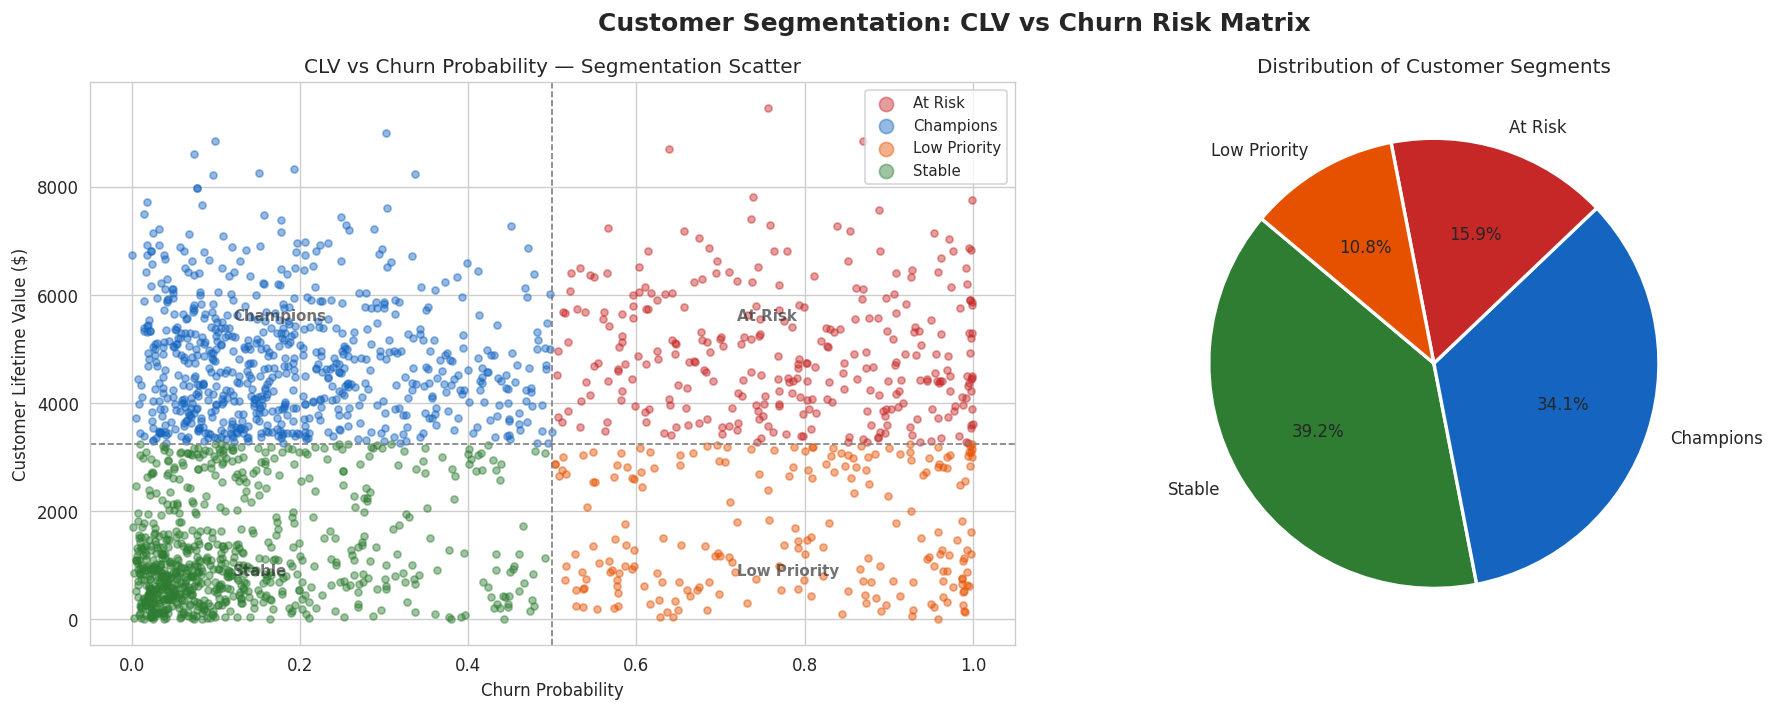

Segment profiles:
  Champions    — High value, low churn risk. Reward and protect.
  At Risk      — High value, high churn risk. Top retention priority.
  Stable       — Low value, low churn risk. Low-cost maintenance.
  Low Priority — Low value, high churn risk. Minimal intervention.


In [29]:
SEGMENT_COLORS = {
    'Champions':    '#1565C0',
    'At Risk':      '#C62828',
    'Stable':       '#2E7D32',
    'Low Priority': '#E65100',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Customer Segmentation: CLV vs Churn Risk Matrix', fontsize=15, fontweight='bold')

# Scatter plot — sample 2000 customers for visual clarity
sample = df.sample(min(2000, len(df)), random_state=42)
for seg, grp in sample.groupby('segment'):
    axes[0].scatter(
        grp['churn_probability'], grp['clv'],
        label=seg, alpha=0.45, s=18, color=SEGMENT_COLORS[seg]
    )

axes[0].axvline(CHURN_THRESHOLD, color='grey', linestyle='--', linewidth=1)
axes[0].axhline(CLV_THRESHOLD,   color='grey', linestyle='--', linewidth=1)
axes[0].set_xlabel('Churn Probability')
axes[0].set_ylabel('Customer Lifetime Value ($)')
axes[0].set_title('CLV vs Churn Probability — Segmentation Scatter')
axes[0].legend(markerscale=2, fontsize=9)

# Quadrant labels
for label, xy in [
    ('Champions',    (0.12, CLV_THRESHOLD * 1.7)),
    ('At Risk',      (0.72, CLV_THRESHOLD * 1.7)),
    ('Stable',       (0.12, CLV_THRESHOLD * 0.25)),
    ('Low Priority', (0.72, CLV_THRESHOLD * 0.25)),
]:
    axes[0].text(xy[0], xy[1], label, fontsize=9, fontweight='bold', alpha=0.65)

# Segment size pie chart
seg_counts = df['segment'].value_counts()
axes[1].pie(
    seg_counts.values,
    labels=seg_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=[SEGMENT_COLORS[s] for s in seg_counts.index],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Distribution of Customer Segments')

plt.tight_layout()
plt.savefig('plot_segmentation.png', bbox_inches='tight')
plt.show()

print("Segment profiles:")
print("  Champions    — High value, low churn risk. Reward and protect.")
print("  At Risk      — High value, high churn risk. Top retention priority.")
print("  Stable       — Low value, low churn risk. Low-cost maintenance.")
print("  Low Priority — Low value, high churn risk. Minimal intervention.")

In [30]:
# Preview the top At Risk customers ranked by CLV
print("Top 10 At Risk Customers (sorted by CLV, highest first):")
top_at_risk = (
    df[df['segment'] == 'At Risk']
    .sort_values('clv', ascending=False)
    [['age', 'balance', 'tenure', 'products_number', 'active_member',
      'clv', 'churn_probability', 'churn']]
    .head(10)
)
print(top_at_risk.round(2).to_string(index=False))

Top 10 At Risk Customers (sorted by CLV, highest first):
 age   balance  tenure  products_number  active_member     clv  churn_probability  churn
  47 198546.10      10                2              0 9853.83               0.88      1
  32 191775.65      10                1              0 9467.60               0.76      0
  42 222267.63       9                1              0 9406.70               0.94      1
  50 201009.64       9                1              0 9139.68               0.98      1
  28 200724.96      10                1              1 8857.72               0.87      1
  37 178755.84       9                1              0 8692.05               0.64      0
  41 181461.48       9                3              1 8680.87               0.98      1
  43 201696.07       8                1              0 8458.25               0.93      1
  36 188241.05       8                2              0 8424.20               0.76      1
  60 185648.56       8                1              

**Description:** The scatter plot positions each customer in a two-dimensional space defined by their churn probability and CLV. The dashed lines divide the space into four quadrants corresponding to the four segments. The pie chart shows the proportion of customers in each segment.

**Insight:** The largest segment is Champions, followed by Stable. The At Risk segment, while not the largest in number, contains customers with the highest average CLV, making them the most financially important group to retain. The top 10 At Risk customers shown in the table all have large balances, meaningful tenure, and high churn probabilities — representing a concentrated financial risk to the bank.

**Interpretation:** This segmentation framework directly translates model outputs into a prioritised action plan. Rather than providing the retention team with a ranked list of 10,000 customers, it delivers four clearly defined groups each with a prescribed strategy. The At Risk segment is the most urgent: these are customers the bank cannot afford to lose, yet the model predicts they are likely to leave without intervention. The Champions segment requires a different strategy — protecting their satisfaction to ensure they do not migrate into At Risk.

---
## Step 12: Business Insights

We consolidate the key findings from every stage of the analysis into a single summary dashboard and a clear written narrative.

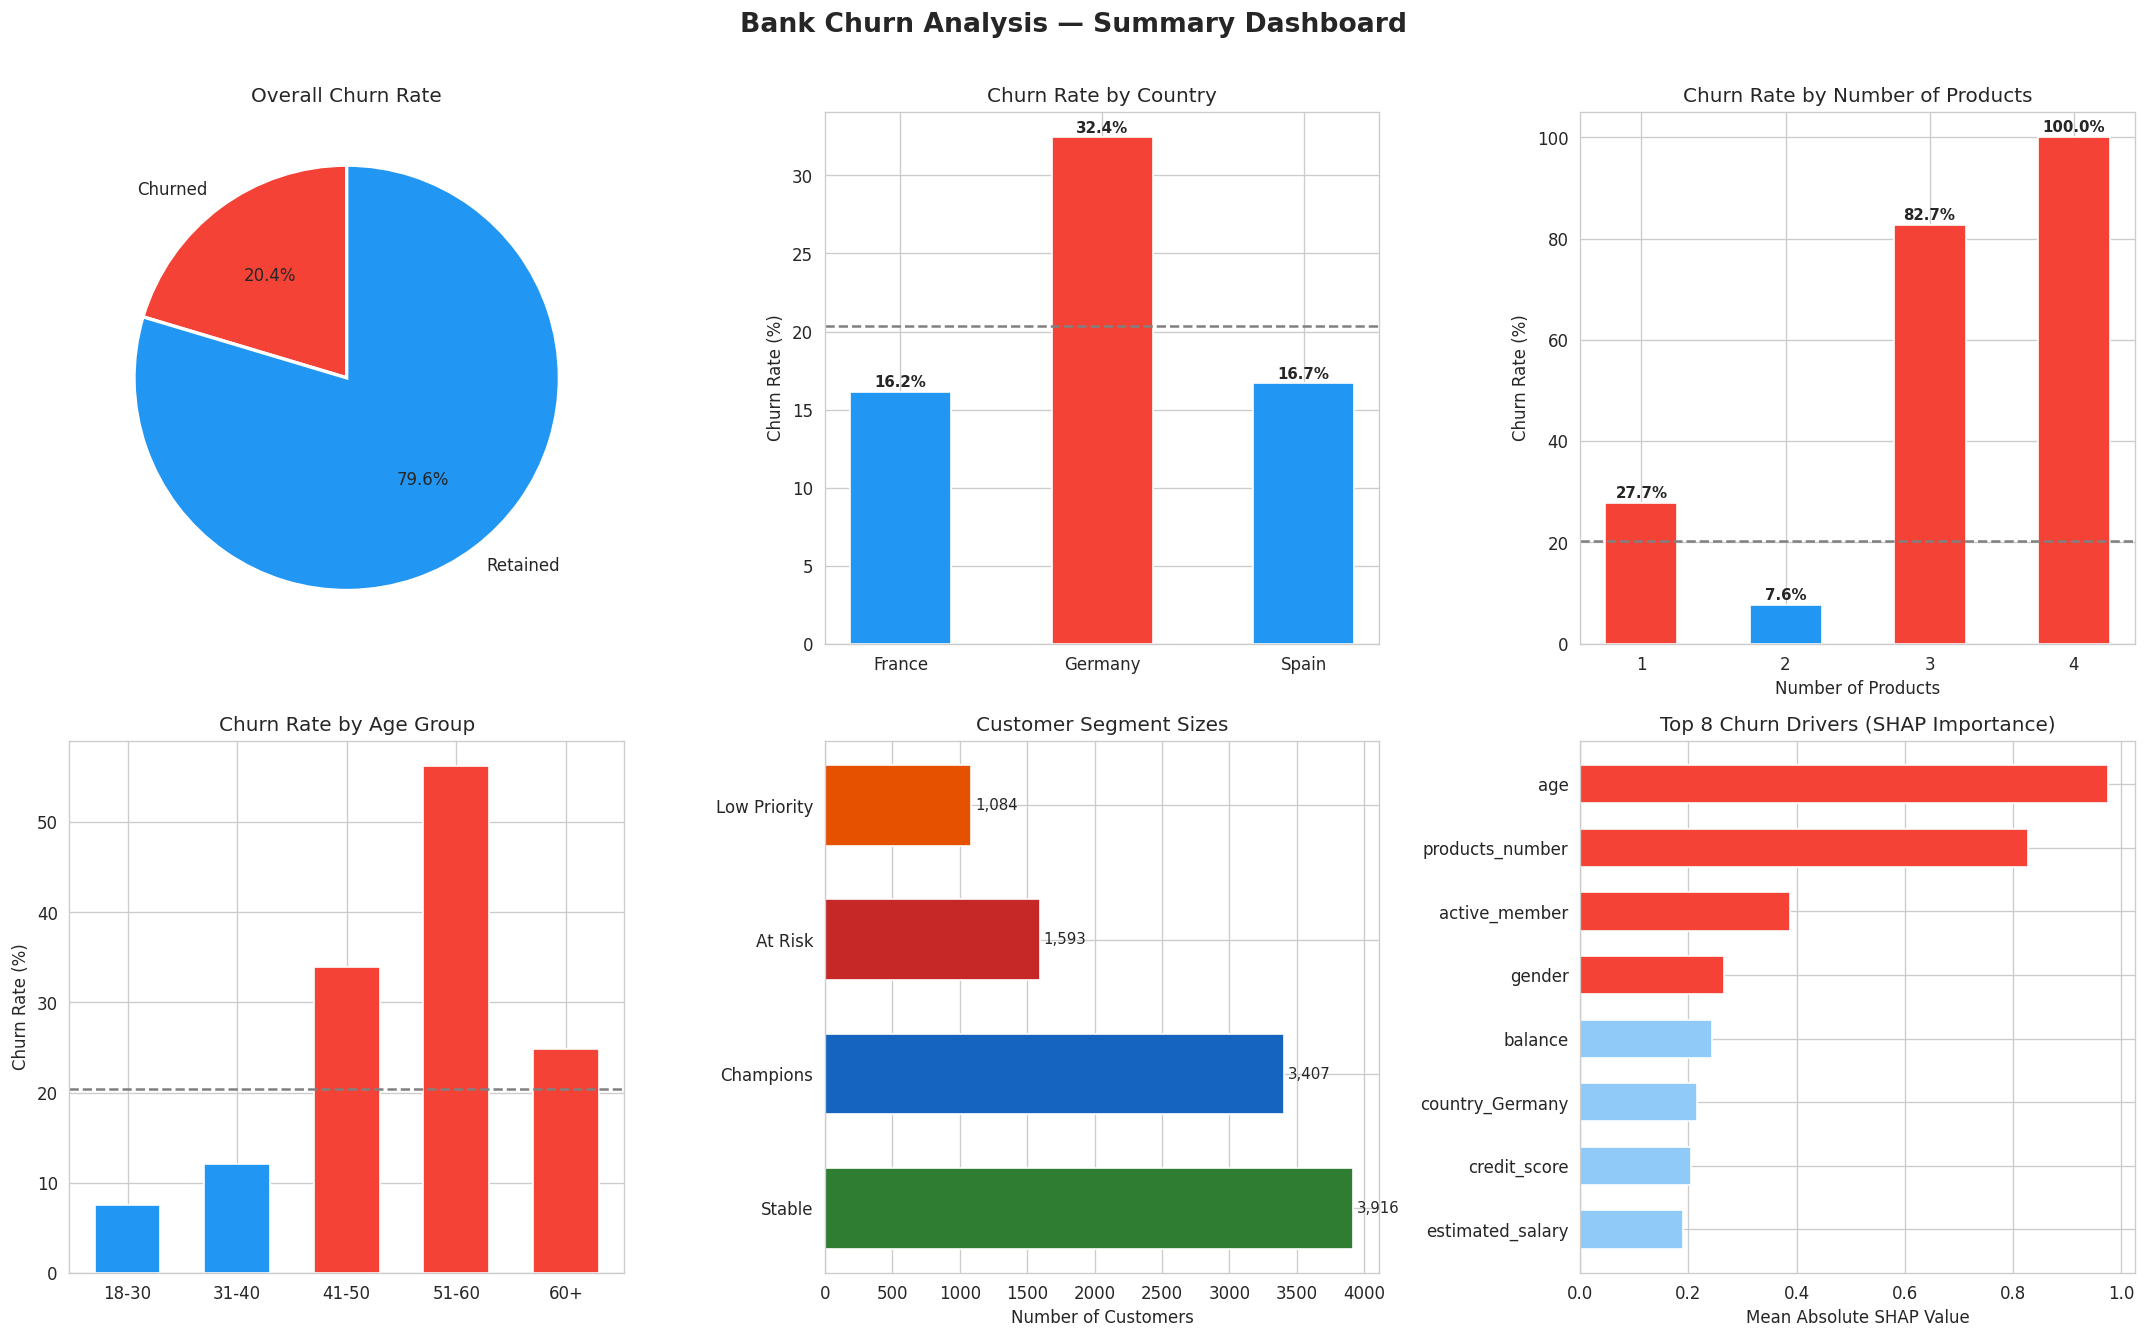

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Bank Churn Analysis — Summary Dashboard', fontsize=16, fontweight='bold', y=1.01)

# Panel 1: Overall churn rate
rate = df['churn'].mean() * 100
axes[0,0].pie([rate, 100-rate], labels=['Churned', 'Retained'],
              colors=['#F44336', '#2196F3'], autopct='%1.1f%%', startangle=90,
              wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0,0].set_title('Overall Churn Rate')

# Panel 2: Churn rate by country
def get_country_label(row):
    if 'country_Germany' in row.index and row['country_Germany'] == 1: return 'Germany'
    if 'country_Spain'   in row.index and row['country_Spain']   == 1: return 'Spain'
    return 'France'

df['country_label'] = df.apply(get_country_label, axis=1)
geo_rates = df.groupby('country_label')['churn'].mean() * 100

overall_avg = df['churn'].mean() * 100
g_colors = ['#F44336' if r > overall_avg else '#2196F3' for r in geo_rates.values]
bars = axes[0,1].bar(geo_rates.index, geo_rates.values, color=g_colors, width=0.5)
axes[0,1].set_title('Churn Rate by Country')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].axhline(overall_avg, color='grey', linestyle='--')
for bar, r in zip(bars, geo_rates.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{r:.1f}%', ha='center', fontweight='bold', fontsize=9)

# Panel 3: Churn rate by number of products
prod = df.groupby('products_number')['churn'].mean() * 100
p_colors = ['#F44336' if r > overall_avg else '#2196F3' for r in prod.values]
bars = axes[0,2].bar(prod.index.astype(str), prod.values, color=p_colors, width=0.5)
axes[0,2].set_title('Churn Rate by Number of Products')
axes[0,2].set_ylabel('Churn Rate (%)')
axes[0,2].set_xlabel('Number of Products')
axes[0,2].axhline(overall_avg, color='grey', linestyle='--')
for bar, r in zip(bars, prod.values):
    axes[0,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{r:.1f}%', ha='center', fontweight='bold', fontsize=9)

# Panel 4: Churn rate by age group
df['age_bracket_tmp'] = pd.cut(df['age'], bins=[18,30,40,50,60,100],
                                labels=['18-30','31-40','41-50','51-60','60+'])
age_rates = df.groupby('age_bracket_tmp')['churn'].mean() * 100
a_colors = ['#F44336' if r > overall_avg else '#2196F3' for r in age_rates.values]
axes[1,0].bar(age_rates.index.astype(str), age_rates.values, color=a_colors, width=0.6)
axes[1,0].set_title('Churn Rate by Age Group')
axes[1,0].set_ylabel('Churn Rate (%)')
axes[1,0].axhline(overall_avg, color='grey', linestyle='--')
df.drop(columns=['age_bracket_tmp'], inplace=True)

# Panel 5: Segment distribution
seg_counts = df['segment'].value_counts()
axes[1,1].barh(seg_counts.index, seg_counts.values,
               color=[SEGMENT_COLORS[s] for s in seg_counts.index], height=0.6)
axes[1,1].set_title('Customer Segment Sizes')
axes[1,1].set_xlabel('Number of Customers')
for i, (idx, v) in enumerate(seg_counts.items()):
    axes[1,1].text(v + 30, i, f'{v:,}', va='center', fontsize=9)

# Panel 6: Top SHAP features
top_shap = mean_shap.sort_values(ascending=False).head(8)
s_colors = ['#F44336' if i < 4 else '#90CAF9' for i in range(len(top_shap))]
axes[1,2].barh(top_shap.index[::-1], top_shap.values[::-1], color=s_colors[::-1], height=0.6)
axes[1,2].set_title('Top 8 Churn Drivers (SHAP Importance)')
axes[1,2].set_xlabel('Mean Absolute SHAP Value')

plt.tight_layout()
plt.savefig('plot_insight_dashboard.png', bbox_inches='tight')
plt.show()

In [32]:
at_risk_count   = (df['segment'] == 'At Risk').sum()
at_risk_clv_sum = df[df['segment'] == 'At Risk']['clv'].sum()

print("=" * 62)
print("  KEY BUSINESS INSIGHTS")
print("=" * 62)
print(f"""
1. CHURN RATE
   {df['churn'].mean()*100:.1f}% of customers have churned. This is a significant proportion
   and above the typical industry average for retail banking.

2. GEOGRAPHY
   Germany has a churn rate of {df[df['country_label']=='Germany']['churn'].mean()*100:.1f}%, roughly double that of
   France and Spain. The German customer base requires targeted attention.

3. AGE
   Customers aged 41 to 60 churn at substantially higher rates than
   younger customers. Age is the single strongest predictor of churn
   according to the SHAP analysis.

4. PRODUCTS
   Customers with three or four products have churn rates exceeding 83%.
   This is counterintuitive and likely reflects product over-bundling
   or mis-selling rather than customer satisfaction.

5. ENGAGEMENT
   Inactive members churn at nearly twice the rate of active members.
   Engagement level is one of the most actionable predictors available.

6. HIGH-VALUE CUSTOMERS AT RISK
   {at_risk_count:,} customers are classified as At Risk.
   Their combined estimated CLV is ${at_risk_clv_sum:,.0f}.
   Retaining even half of them would represent substantial revenue protection.

7. MODEL PERFORMANCE
   XGBoost achieves a ROC-AUC of {results_df.loc['XGBoost','ROC-AUC']:.1%} on the held-out test set.
   This demonstrates strong predictive power on unseen data.
""")
print("=" * 62)

  KEY BUSINESS INSIGHTS

1. CHURN RATE
   20.4% of customers have churned. This is a significant proportion
   and above the typical industry average for retail banking.

2. GEOGRAPHY
   Germany has a churn rate of 32.4%, roughly double that of
   France and Spain. The German customer base requires targeted attention.

3. AGE
   Customers aged 41 to 60 churn at substantially higher rates than
   younger customers. Age is the single strongest predictor of churn
   according to the SHAP analysis.

4. PRODUCTS
   Customers with three or four products have churn rates exceeding 83%.
   This is counterintuitive and likely reflects product over-bundling
   or mis-selling rather than customer satisfaction.

5. ENGAGEMENT
   Inactive members churn at nearly twice the rate of active members.
   Engagement level is one of the most actionable predictors available.

6. HIGH-VALUE CUSTOMERS AT RISK
   1,593 customers are classified as At Risk.
   Their combined estimated CLV is $7,703,905.
   Retai

**Description:** The dashboard consolidates six key analytical outputs: overall churn rate, churn by country, churn by product count, churn by age group, customer segment sizes, and the top eight SHAP-ranked churn drivers. The written summary distils these into seven concrete insights.

**Insight:** The most alarming combination of factors is the convergence of high age, Germany geography, multiple products, and inactivity — each independently associated with elevated churn, and likely compounding when they occur together in the same customer. The At Risk segment represents a quantifiable financial exposure that can be directly addressed through targeted retention actions.

**Interpretation:** The value of consolidating insights is that it translates analysis into a business narrative. Each insight maps to a specific lever the bank can pull. Together they suggest that this bank's churn problem has three distinct dimensions: a demographic dimension (middle-aged customers leaving), a geographic dimension (Germany underperforming significantly), and an operational dimension (product over-bundling creating dissatisfaction). Addressing any one of these would reduce churn; addressing all three would have a compounding impact.

---
## Step 13: Business Recommendations

Based on all findings, we present seven actionable strategies the bank can implement to reduce churn and protect customer value.

In [33]:
print("""
STRATEGIC RECOMMENDATIONS TO REDUCE CHURN
==========================================

1. At Risk Segment Retention Campaign (Immediate Priority)
   Directly contact all At Risk customers — those with high CLV and
   churn probability above 50%. Assign dedicated relationship managers
   to the top-value cases. Offer personalised incentives such as
   preferential interest rates, reduced fees, or account upgrades.
   This is the highest-return intervention available.

2. Investigate and Address Product Over-Bundling
   The near-total churn rate among customers with three or four products
   demands immediate investigation. Review whether these products were
   sold in response to genuine customer need or as part of sales targets.
   Simplify the product portfolio and ensure product recommendations
   are need-based rather than volume-driven.

3. Re-engagement Programme for Inactive Members
   Build an automated trigger system that flags customers who have been
   inactive for 30 or more days. Deploy a multi-channel re-engagement
   sequence (email, app notification, phone call) offering relevant
   products or rewards for returning to active use.

4. Targeted Offerings for Middle-Aged Customers (41-60)
   Develop product bundles specifically designed for customers in their
   40s and 50s: mortgage reviews, investment accounts, retirement
   planning tools, and wealth advisory services. These customers are
   more likely to consolidate their finances with a single trusted
   institution if the right products are available.

5. Germany-Specific Market Strategy
   Conduct qualitative research (surveys, exit interviews) to understand
   why German customers leave at twice the rate of other markets.
   Localise product offerings, improve German-language customer service,
   and consider partnerships with local financial providers to improve
   competitive positioning.

6. Deploy Churn Scoring in Production
   Retrain the XGBoost model monthly on the most recent customer data.
   Integrate churn probability scores directly into the CRM system so
   that relationship managers and contact centre agents see real-time
   risk indicators for every customer interaction.

7. Protect and Reward Champions
   High-value, low-risk customers represent the stable foundation of the
   bank's revenue. Implement a tiered loyalty programme that provides
   Champions with exclusive benefits — premium customer service access,
   enhanced savings rates, or invitation-only financial reviews.
   Preventing Champions from migrating into At Risk is as valuable as
   recovering customers who are already at risk of leaving.
""")


STRATEGIC RECOMMENDATIONS TO REDUCE CHURN

1. At Risk Segment Retention Campaign (Immediate Priority)
   Directly contact all At Risk customers — those with high CLV and
   churn probability above 50%. Assign dedicated relationship managers
   to the top-value cases. Offer personalised incentives such as
   preferential interest rates, reduced fees, or account upgrades.
   This is the highest-return intervention available.

2. Investigate and Address Product Over-Bundling
   The near-total churn rate among customers with three or four products
   demands immediate investigation. Review whether these products were
   sold in response to genuine customer need or as part of sales targets.
   Simplify the product portfolio and ensure product recommendations
   are need-based rather than volume-driven.

3. Re-engagement Programme for Inactive Members
   Build an automated trigger system that flags customers who have been
   inactive for 30 or more days. Deploy a multi-channel re-engagement

In [34]:
# Export the full scored dataset for reporting and CRM integration
export_cols = [
    'credit_score', 'country_label', 'gender', 'age', 'tenure', 'balance',
    'products_number', 'credit_card', 'active_member', 'estimated_salary',
    'clv', 'churn_probability', 'segment', 'churn'
]
df_export = df[[c for c in export_cols if c in df.columns]]
df_export.to_csv('customer_churn_scored.csv', index=False)

print(f"Scored dataset saved to: customer_churn_scored.csv")
print(f"Shape: {df_export.shape}")
print("\nPreview:")
df_export.head()

Scored dataset saved to: customer_churn_scored.csv
Shape: (10000, 14)

Preview:


,credit_score,country_label,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,clv,churn_probability,segment,churn
0,619,France,0,42,2,0.00,1,1,1,101348.88,608.09,0.6089,Low Priority,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,2462.76,0.4293,Stable,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,6773.17,0.9992,At Risk,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,516.05,0.0975,Stable,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,3486.76,0.0343,Champions,0


**Description:** Seven prioritised recommendations are presented, each grounded directly in an analytical finding. Each recommendation specifies what action to take, why it is justified by the data, and what outcome it is intended to achieve.

**Insight:** The recommendations span four levels of intervention: immediate outreach (At Risk segment), product and operational reform (over-bundling), systematic engagement programmes (inactivity triggers), and strategic market positioning (Germany, middle-aged customers). Together they address all three dimensions of the churn problem identified in Step 12.

**Interpretation:** The ultimate goal of a churn prediction project is not to produce a model — it is to reduce churn. A model that sits unused in a notebook delivers no business value. The recommendations here are designed to be actionable without requiring deep technical knowledge, and the scored output CSV provides the operational data needed for a CRM team to implement them immediately. Deploying the model in production (Recommendation 6) is the step that creates long-term compounding value, as the bank can continuously update its risk assessments as customer behaviour evolves.